In [11]:
!pip install SoccerNet
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.0/67.0 MB 8.5 MB/s  0:00:07 eta 0:00:010:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 8.9 MB/s  0:00:01 eta 0:00:010:01:01
  Attempting uninstall: numpy
    Found existing installation: numpy 2.3.4
    Uninstalling numpy-2.3.4:
      Successfully uninstalled numpy-2.3.4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [opencv-python]m 1/2 [opencv-python]


In [12]:
import matplotlib.pyplot as plt
import json
import os
import cv2

In [ ]:
from SoccerNet.Downloader import SoccerNetDownloader
mySoccerNetDownloader = SoccerNetDownloader(LocalDirectory="/content")
mySoccerNetDownloader.downloadGames(files=["Labels-v3.json", "Frames-v3.zip"], split=["train","valid","test"], task="frames") # download frames and labels for the 400 games of SN v3 - Requires around 60 GB of local storage

KeyboardInterrupt: 

In [ ]:
!unzip /content/Frames-v3.zip

Archive:  /content/Frames-v3.zip
  inflating: 10_0.png                
  inflating: 1_3.png                 
  inflating: 6_1.png                 
  inflating: 19_1.png                
  inflating: 15.png                  
  inflating: 1.png                   
  inflating: 0.png                   
  inflating: 13.png                  
  inflating: 19_0.png                
  inflating: 5_0.png                 
  inflating: 1_4.png                 
  inflating: 12_1.png                
  inflating: 21_0.png                
  inflating: 13_0.png                
  inflating: 16.png                  
  inflating: 18_1.png                
  inflating: 11_0.png                
  inflating: 20_3.png                
  inflating: 1_5.png                 
  inflating: 4.png                   
  inflating: 12_0.png                
  inflating: 22_0.png                
  inflating: 15_0.png                
  inflating: 17.png                  
  inflating: 3.png                   
  inflating: 2_0.

In [2]:
from SoccerNet.utils import getListGames
from SoccerNet.Downloader import SoccerNetDownloader
import os
import json
import random

# 1. Initialize downloader
downloader = SoccerNetDownloader(LocalDirectory="content")

# Optional: if you have NDA access for videos
downloader.password = "s0cc3rn3t"

# 2. List available games (e.g. training split)
games = getListGames(split="train")
print(f"Total games found: {len(games)}")

# 3. Pick a small subset of games
subset = random.sample(games, 2)
print("Chosen games:", subset)

# 4. Download those specific games (no 'split' argument)
files_to_download = ["Labels-v2.json", "1_224p.mkv"]

for game in subset:
    print(f"Downloading {game}...")
    downloader.downloadGame(game=game, files=files_to_download)

print("✅ Download complete!")

# 5. Load labels for one of the downloaded games
def load_labels(local_dir, game):
    for root, dirs, files in os.walk(os.path.join(local_dir, game)):
        for f in files:
            if f.lower().endswith("labels-v2.json"):
                with open(os.path.join(root, f)) as fp:
                    return json.load(fp)
    return None

labels = load_labels("content", subset[0])
if labels:
    print(f"Loaded labels for {subset[0]}:", labels.keys())
else:
    print("No labels found for the selected game.")


/home/jota/Desktop/uni/magistrale/computer_vision/MatchSense/.conda/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Total games found: 300
Chosen games: ['france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes', 'spain_laliga/2016-2017/2016-11-19 - 18-15 Barcelona 0 - 0 Malaga']


✅ Download complete!
Loaded labels for france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes: dict_keys(['UrlLocal', 'UrlYoutube', 'annotations', 'gameAwayTeam', 'gameDate', 'gameHomeTeam', 'gameScore'])


In [3]:
for label in labels["annotations"]:
  print(label)

{'gameTime': '1 - 00:00', 'label': 'Kick-off', 'position': '0', 'team': 'home', 'visibility': 'not shown'}
{'gameTime': '1 - 00:37', 'label': 'Ball out of play', 'position': '37150', 'team': 'not applicable', 'visibility': 'visible'}
{'gameTime': '1 - 00:51', 'label': 'Throw-in', 'position': '51320', 'team': 'home', 'visibility': 'not shown'}
{'gameTime': '1 - 01:20', 'label': 'Ball out of play', 'position': '80922', 'team': 'not applicable', 'visibility': 'visible'}
{'gameTime': '1 - 01:37', 'label': 'Throw-in', 'position': '97042', 'team': 'away', 'visibility': 'not shown'}
{'gameTime': '1 - 02:09', 'label': 'Ball out of play', 'position': '129932', 'team': 'not applicable', 'visibility': 'visible'}
{'gameTime': '1 - 02:17', 'label': 'Throw-in', 'position': '137685', 'team': 'away', 'visibility': 'not shown'}
{'gameTime': '1 - 02:53', 'label': 'Shots on target', 'position': '173270', 'team': 'away', 'visibility': 'visible'}
{'gameTime': '1 - 04:08', 'label': 'Ball out of play', 'posi

In [4]:
!git clone https://github.com/SoccerNet/sn-spotting.git

Cloning into 'sn-spotting'...
remote: Enumerating objects: 439, done.
remote: Counting objects: 100% (129/129), done.
remote: Compressing objects: 100% (79/79), done.
remote: Total 439 (delta 82), reused 78 (delta 46), pack-reused 310 (from 1)
Receiving objects: 100% (439/439), 252.86 MiB | 8.22 MiB/s, done.
Resolving deltas: 100% (163/163), done.
Updating files: 100% (185/185), done.


In [5]:
pip install pyqt5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 8.3 MB/s  0:00:01m 9.5 MB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 MB 8.9 MB/s  0:00:06 eta 0:00:010:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3/3 [pyqt5]━━━━━━━━━━━━ 2/3 [pyqt5]
Note: you may need to restart the kernel to use updated packages.


In [6]:
!cd sn-spotting/Annotation/src/ && python main.py

QSocketNotifier: Can only be used with threads started with QThread
qt.qpa.wayland: EGL not available

(python:39279): GStreamer-WARNING **: 18:22:23.678: Failed to load plugin '/usr/lib/x86_64-linux-gnu/gstreamer-1.0/libgstlibav.so': /home/jota/Desktop/uni/magistrale/computer_vision/MatchSense/.conda/bin/../lib/libstdc++.so.6: version `GLIBCXX_3.4.32' not found (required by /lib/x86_64-linux-gnu/libavfilter.so.9)
^C


Action: Kick-off at 1 - 00:00


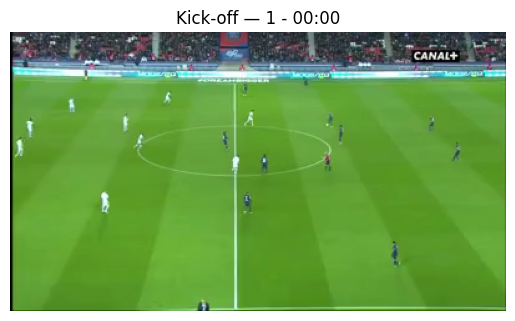

Action: Ball out of play at 1 - 00:37
⚠️ Could not read frame at 928750 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Throw-in at 1 - 00:51
⚠️ Could not read frame at 1283000 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Ball out of play at 1 - 01:20
⚠️ Could not read frame at 2023050 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Throw-in at 1 - 01:37
⚠️ Could not read frame at 2426050 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Ball out of play at 1 - 02:09
⚠️ Could not read frame at 3248300 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Throw-in at 1 - 02:17
⚠️ Could not read frame at 3442125 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Shots on target at 1 - 02:53
⚠️ C

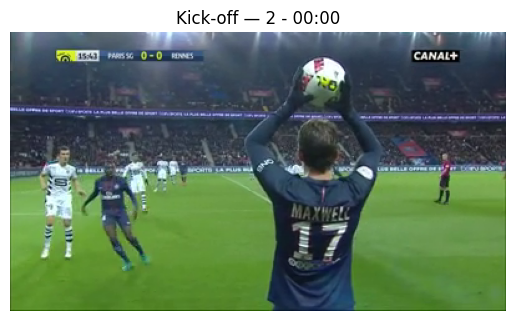

Action: Shots off target at 2 - 01:20
⚠️ Could not read frame at 2022350 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Ball out of play at 2 - 01:21
⚠️ Could not read frame at 2036350 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Clearance at 2 - 01:39
⚠️ Could not read frame at 2476125 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Offside at 2 - 01:52
⚠️ Could not read frame at 2823625 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Indirect free-kick at 2 - 02:14
⚠️ Could not read frame at 3366000 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Foul at 2 - 02:30
⚠️ Could not read frame at 3772450 from content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes//1_224p.mkv
Action: Yellow card at 2 - 02:43
⚠️ Could 

In [ ]:
# Load labels
labels_path = f"content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes/Labels-v2.json"

# Example paths (adjust these to your dataset)
game = f"content/france_ligue-1/2016-2017/2016-11-06 - 22-45 Paris SG 4 - 0 Rennes/"
video_path = f"{game}/1_224p.mkv"   # or whichever mkv (1.mkv, 2.mkv, etc.)
labels_path = f"{game}/Labels-v2.json"

# Load labels
with open(labels_path, "r") as f:
    labels = json.load(f)

for i, label in enumerate(labels["annotations"]):
    # Pick one label to visualize
    action = labels["annotations"][i]
    print("Action:", action["label"], "at", action["gameTime"])

    # Open video
    cap = cv2.VideoCapture(video_path)

    # Convert label position (usually in seconds)
    time_sec = float(action["position"])
    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_index = int(time_sec * fps)

    # Seek to the frame
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_index)

    # Read frame
    success, frame = cap.read()
    cap.release()

    if success:
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        plt.imshow(frame)
        plt.title(f"{action['label']} — {action['gameTime']}")
        plt.axis("off")
        plt.show()
    else:
        print("⚠️ Could not read frame at", frame_index, "from", video_path)